# Árbol de decisión

A lo largo de los siguientes ejercicios, aprenderás a construir e interpretar un modelo de árbol de decisión con scikit-learn. Antes de comenzar con este ejercicio de programación, recomendamos encarecidamente ver la conferencia en video de los temas asociados.

Este cuaderno contiene el código utilizado en dos videos instructivos de la Semana 4: Modelado basado en árboles. Comienza desde el principio para seguir el video, Construir un árbol de decisión con Python.


In [ ]:
import numpy as np
import pandas as pd
import platform
import sklearn
import xgboost as xgb
print('Python version: ', platform.python_version())
print('numpy version: ', np.__version__)
print('pandas version: ', pd.__version__)
print('sklearn version ', sklearn.__version__)
print('xgboost version ', xgb.__version__) 

Python version:  3.13.7
numpy version:  2.4.2
pandas version:  3.0.0
sklearn version  1.8.0
xgboost version  3.4.0


Todo la información que necesitas para resolver esta tarea está en este cuaderno, y todo el código que implementarás tendrá lugar dentro de este cuaderno.


Temas de enfoque incluyen:

* Declaraciones de importación relevantes
* Selección de una métrica de evaluación
* Codificación de características categóricas como variables ficticias
* Estratificación durante la división de datos
* Ajuste de un modelo
* Evaluación del modelo usando precisión, recall y puntuación F1
* Trazado del árbol de decisión y examen de sus divisiones


A medida que avanzamos, puedes encontrar instrucciones sobre cómo instalar las bibliotecas requeridas a medida que surjan en este cuaderno.


## Objetivo del modelado

El objetivo del modelado es construir y probar un modelo de árbol de decisión que utilice datos bancarios para predecir si un cliente abandonará. Si un cliente abandona, significa que dejó el banco y llevó su negocio a otro lugar. Si podemos predecir a los clientes que probablemente abandonarán, podemos tomar medidas para retenerlos antes de que lo hagan. Estas medidas podrían ser promociones, descuentos u otros incentivos para aumentar la satisfacción del cliente y, por lo tanto, la retención.


### Diseño del modelo y variable objetivo

Nuestro diccionario de datos muestra que hay una columna llamada `Exited`. Este es un valor booleano que indica si un cliente dejó o no el banco (0 = no dejó, 1 = dejó). Esta será nuestra variable objetivo. En otras palabras, para cada cliente, nuestro modelo debe predecir si deben tener un 0 o un 1 en la columna `Exited`.

Esta es una tarea de clasificación porque estamos tratando de predecir en una clase binaria. Por lo tanto, usaremos un modelo `DecisionTreeClassifier`.


### Una nota sobre el flujo de trabajo de modelado y la selección de modelos

Este cuaderno se usa junto con otros cuadernos en este curso que modelan los mismos datos. Debido a esto, construiremos todos nuestros modelos a través de todos estos cuadernos, y la selección de modelos tendrá lugar en el cuaderno final. El modelo campeón será aquel que tenga el mejor rendimiento en los datos de validación. Solo este modelo final será evaluado usando los datos de prueba.

Este enfoque tiene una limitación. Estamos usando los mismos datos para ajustar los hiperparámetros que los que usamos para realizar la selección de modelos. Esto corre el riesgo de sobreajustar potencialmente el modelo a los datos de validación.

Idealmente, con suficiente tiempo y datos, ajustaríamos los hiperparámetros de los modelos, luego calificaríamos todos los modelos en datos de validación _separados_ y realizaríamos la selección de modelos en función de estas puntuaciones. Finalmente, el modelo campeón sería calificado en los datos de reserva de prueba para obtener una estimación de cómo se puede esperar que el modelo rinda en datos nuevos y no vistos.


<a id='1'></a>
# Construir un árbol de decisión con Python


## Declaraciones de importación

Antes de comenzar con los ejercicios y analizar los datos, necesitamos importar todas las bibliotecas y extensiones requeridas para este ejercicio de programación. A lo largo del curso, utilizaremos numpy y pandas para operaciones, y matplotlib para graficar.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# funcion para dividir el dataset en train y test
from sklearn.model_selection import train_test_split
# modelo de arbol para clasificacion
from sklearn.tree import DecisionTreeClassifier

# Este código es para mostrar los splits del árbol
from sklearn.tree import plot_tree

# métricas de evaluación
# matriz de confusión
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
# métricas de evaluación
from sklearn.metrics import recall_score, precision_score, f1_score, accuracy_score

## Leer los datos


In [3]:
# Read in data
# leer los datos
file = 'Churn_Modelling.csv'
df_original = pd.read_csv(file)
df_original.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


## Examine the data

En este punto en un proyecto típico de ciencia de datos, harías un análisis exploratorio de datos (EDA) exhaustivo para entender mejor tus datos y lo que te están diciendo. Para los propósitos de este laboratorio, lo omitiremos.

En los pasos que siguen, realizaremos muchos de los mismos pasos que tomamos para construir nuestro modelo de Naive Bayes. Los repetiremos aquí para revisarlos por buena medida.

Comenzaremos verificando el equilibrio de las clases en nuestra variable objetivo (`Exited`), ya que esto nos ayudará a determinar cómo preparar nuestros datos. También informará nuestra decisión de qué métrica de evaluación usar para seleccionar nuestro modelo final.


In [4]:
# Check class balance
# Chequear el balance de clases
df_original['Exited'].value_counts()

Exited
0    7963
1    2037
Name: count, dtype: int64

La clase de nuestra variable objetivo se divide aproximadamente en 80/20. En otras palabras, ~20% de las personas en este conjunto de datos abandonaron. Este es un conjunto de datos desequilibrado, pero no extremo. Preservaremos esta proporción cuando modelemos.


## Seleccionar una métrica de evaluación

Los datos contienen 10,000 observaciones, y la distribución de clases es aproximadamente 80/20.

Dado que tenemos un cierto desequilibrio en nuestras clases objetivo, sabemos que si medimos el rendimiento del modelo solo por precisión, el modelo podría predecir 0 (sin cancelación) el 100% del tiempo y tener una precisión de aproximadamente 80%. Una precisión del 80% podría parecer bastante buena, pero sabemos que en este caso sería inútil, porque nuestro modelo no sería capaz de identificar a nadie que cancelara. Por lo tanto, la precisión no es la mejor métrica para evaluar el rendimiento de nuestro modelo.

Para determinar qué métrica de evaluación podría ser la mejor, considera cómo podría estar equivocado nuestro modelo. Hay dos posibilidades para predicciones incorrectas:

  - **Falsos positivos:** Cuando el modelo predice que un cliente **cancelará** cuando en realidad no lo hará
  - **Falsos negativos:** Cuando el modelo predice que un cliente **no cancelará** cuando en realidad sí lo hará

Como sabes, hay varias métricas de rendimiento además de la precisión para elegir. Algunas de estas incluyen precisión, recall y puntuación F1. Examinemos estas más de cerca, comenzando con _precisión:_

$$
precision = \frac{\text{VP}}{\text{FP+VP}}
$$
  </br> 

Y _recall:_ 

$$
recall = \frac{\text{VP}}{\text{FN+VP}}
$$  
  </br>
  
Consulta la matriz de confusión para un recordatorio de lo que representan los términos.


![](ADA_R-260_notebook_confusion_matrix.png)

La precisión representa el porcentaje de todos los positivos predichos por nuestro modelo que son verdaderos positivos. Esto podría no ser la mejor métrica para usar, porque desincentiva predecir que alguien abandonará a menos que haya un alto grado de certeza de que lo hará. Esto podría traducirse en una alta tasa de falsos negativos.

Por otro lado, la recuperación representa el porcentaje de todos los positivos reales que el modelo identifica como tales. Esto también podría no ser la mejor métrica para usar, porque recompensa predecir que alguien abandonará incluso si la probabilidad de que lo haga es muy pequeña. Esto podría traducirse en una alta tasa de falsos positivos.

Entonces, ¿qué es peor, falsos positivos o falsos negativos? Bueno, primero tendríamos que definir qué significa _peor_. Esto depende de los detalles del proyecto en el que estás trabajando. Para el propósito de este ejercicio, supongamos que lo estamos definiendo como el error que le costaría más dinero al banco.

Podemos obtener rápidamente una idea de cuánto dinero le cuesta a la banca cada cliente que abandona calculando el saldo promedio de todos los clientes que abandonaron.


In [5]:
# Calculate average balance of customers who churned
# Calcular el balance promedio de los clientes que se dieron de baja
avg_churned_bal = df_original[df_original['Exited']==1]['Balance'].mean()
avg_churned_bal

np.float64(91108.53933726068)

Esto muestra que los clientes que abandonaron cada uno se llevaron €91,108.54, en promedio. ¡Eso es mucho dinero! Esto representa el costo promedio del modelo al predecir un falso negativo.

¿Cuál es el costo de predecir un falso positivo? Bueno, es el costo de cualquier incentivo que pueda haber para convencer a alguien de quedarse en el banco cuando iban a quedarse independientemente de si fueron incentivados o no. No tenemos un número para esto, e incluso si probablemente sea menor que €91,108.54, todavía podría ser miles de euros por cliente en ingresos perdidos, dependiendo de los detalles del incentivo.


Dado que identificar correctamente a los clientes que abandonarán es potencialmente muy valioso, nosotros *podríamos* seleccionar el recall como nuestra métrica más importante. Esto podría ser un enfoque perfectamente válido, dependiendo de los detalles de la campaña. Pero esto también podría ser problemático. Después de todo, si seleccionamos un modelo basado únicamente en el recall, podríamos seleccionar un modelo muy sesgado que predice que todos abandonarán, pero entonces 8,000 personas serían incentivadas innecesariamente.  

Dado que no conocemos el costo exacto de predecir un falso negativo, haremos una suposición para este ejercicio. Supondremos que una métrica que equilibra precisión y recall es la mejor. La métrica que nos ayuda a lograr este equilibrio es _F1 score_, que se define como la media armónica de precisión y recall. 

$$
{F_{1}} = 2 \cdot \frac{precision \cdot  recall}{precision + recall} 
$$


De nuevo, hay muchas métricas para elegir. Lo importante es que tomes una decisión informada que esté basada en tu caso de uso.

Ahora que hemos decidido una métrica de evaluación, preparemos los datos para el modelado.


## Ingeniería de características


### Selección de características

En este paso, prepararemos los datos para el modelado. Estos son los mismos pasos que hicimos para el modelo Naive Bayes. Para una explicación más detallada de este proceso, consulte el [cuaderno de Ingeniería de características del Módulo 3](https://www.coursera.org/learn/the-nuts-and-bolts-of-machine-learning/ungradedLab/5w1w8/annotated-follow-along-resource-feature-engineering-with-python). Tenga en cuenta que por consideraciones de tiempo, no crearemos nuevas características.

Comenzamos eliminando las columnas que no esperaríamos que ofrezcan ninguna señal predictiva al modelo. Estas columnas incluyen `RowNumber`, `CustomerID` y `Surname`. Eliminaremos estas columnas para que no introduzcan ruido en nuestro modelo.

También eliminaremos la columna `Gender`, porque no queremos que nuestro modelo haga predicciones basadas en el género.


In [6]:
# Create a new df that drops RowNumber, CustomerId, Surname, and Gender cols
# Crear un nuevo df que elimine las columnas RowNumber, CustomerId, Surname y Gender
churn_df = df_original.drop(['RowNumber', 'CustomerId', 'Surname', 'Gender'], 
                            axis=1)

In [7]:
churn_df.head()

,CreditScore,Geography,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,41,1,83807.86,1,0,1,112542.58,0
2,502,France,42,8,159660.80,3,1,0,113931.57,1
3,699,France,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,43,2,125510.82,1,1,1,79084.10,0


### Transformación de características

A continuación, codificaremos en variables ficticias la variable `Geography`, que es categórica. Hay tres categorías posibles capturadas aquí: Francia, España y Alemania. Cuando llamamos a `pd.get_dummies()` en esta característica, reemplazará la columna `Geography` por tres nuevas columnas Booleanas, una para cada categoría posible contenida en la columna que se está codificando en variables ficticias.

Cuando especificamos `drop_first='True'` en la llamada a la función, significa que en lugar de reemplazar `Geography` con tres columnas nuevas, se reemplazará con dos columnas. Podemos hacer esto porque no se pierde información de esto, pero el conjunto de datos es más corto y simple.

En este caso, terminamos con dos columnas nuevas llamadas `Geography_Germany` y `Geography_Spain`. No necesitamos una columna `Geography_France`. ¿Por qué no? Porque si los valores de un cliente en `Geography_Germany` y `Geography_Spain` son ambos 0, ¡sabremos que son de Francia!


In [8]:
# Dummy encode categorical variables
# Transformar variables categóricas en variables dummy con eliminación de la primera categoría para evitar multicolinealidad
churn_df = pd.get_dummies(churn_df, drop_first=True)

In [9]:
churn_df.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain
0,619,42,2,0.00,1,1,1,101348.88,1,False,False
1,608,41,1,83807.86,1,0,1,112542.58,0,False,True
2,502,42,8,159660.80,3,1,0,113931.57,1,False,False
3,699,39,1,0.00,2,0,0,93826.63,0,False,False
4,850,43,2,125510.82,1,1,1,79084.10,0,False,True


## Dividir los datos

Es hora de dividir los datos en características y variable objetivo, y en datos de entrenamiento y datos de prueba. Hacemos esto usando la función `train_test_split()`. Pondremos el 25% de los datos en nuestro conjunto de prueba, y usaremos el 75% restante para entrenar el modelo.

No olvides incluir el parámetro `stratify=y`, ya que esto asegura que la proporción de clases 80/20 de la variable objetivo se mantenga en ambos conjuntos de datos, de entrenamiento y de prueba, después de la división.

Por último, establecemos una semilla aleatoria para que nosotros y otros podamos reproducir nuestro trabajo.


In [10]:
# Define the y (target) variable
# Definir la variable y (objetivo)
y = churn_df['Exited']

# Define the X (predictor) variables
# Definir las variables X (predictoras)
X = churn_df.copy()
X = X.drop('Exited', axis=1)

# Split into train and test sets
# Dividir en conjuntos de entrenamiento y prueba con estratificación para mantener la proporción de clases

X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size=0.25, stratify=y, 
                                                    random_state=42)

## Modelo base

Primero entrenaremos un modelo base, solo para tener una idea de qué tan predictivos son los datos y para darnos puntuaciones que podamos consultar más tarde. Esto también mostrará el proceso de instanciar y ajustar el modelo, y luego usarlo para hacer predicciones. Prediciremos en los datos de prueba.<br>


In [11]:
# Instantiate the model
# Instanciar el modelo
decision_tree = DecisionTreeClassifier(random_state=0)

# Fit the model to training data
# Entrenar el modelo con los datos de entrenamiento
decision_tree.fit(X_train, y_train)

# Make predictions on test data
# Hacer predicciones con los datos de prueba
dt_pred = decision_tree.predict(X_test)

In [12]:
# Generate performance metrics
print(f"Accuracy  : {accuracy_score(y_test, dt_pred):.3f}")
print(f"Precision : {precision_score(y_test, dt_pred):.3f}")
print(f"Recall    : {recall_score(y_test, dt_pred):.3f}")
print(f"F1 Score  : {f1_score(y_test, dt_pred):.3f}")

Accuracy  : 0.790
Precision : 0.486
Recall    : 0.503
F1 Score  : 0.494


Una comparación de las puntuaciones F1 revela que el árbol de decisión es una mejora respecto al modelo de Naive Bayes que construimos anteriormente. Para referencia, aquí están las puntuaciones de ambos modelos:

| Modelo | F1 | Recall | Precisión | Exactitud |
| :- | :-: | :-: | :-: | :-: |
| Árbol de Decisión | 0.494 | 0.503 | 0.486 | 0.790 |
| Naive Bayes | 0.456 | 0.369 | 0.597 | 0.821 |


### Análisis del modelo base


#### Matriz de confusión

Vamos a inspeccionar la matriz de confusión de las predicciones de nuestro árbol de decisión. Primero, escribiremos una función auxiliar corta para ayudarnos a mostrar la matriz.


In [13]:
def conf_matrix_plot(model, x_data, y_data):
    '''
    Accepts as argument model object, X data (test or validate), and y data (test or validate). 
    Returns a plot of confusion matrix for predictions on y data.

    Argumentos:
        model: objeto del modelo (por ejemplo, DecisionTreeClassifier)
        x_data: datos de entrada (X) para hacer predicciones (por ejemplo, X_test o X_validate)
        y_data: datos de salida (y) reales para comparar con las predicciones (por ejemplo, y_test o y_validate)
    
    returns:
        Devuelve un gráfico de la matriz de confusión para las predicciones sobre los datos y

    ''' 
  
    model_pred = model.predict(x_data)
    cm = confusion_matrix(y_data, model_pred, labels=model.classes_)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                             display_labels=model.classes_)
  
    disp.plot(values_format='')  # `values_format=''` suppresses scientific notation
    plt.show()

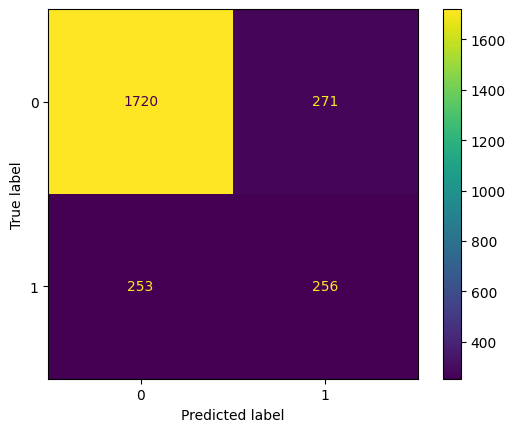

In [15]:
# Generate confusion matrix
# generar matriz de confusión
conf_matrix_plot(decision_tree, X_test, y_test)

Notice from this confusion matrix that the model correctly predicts many true negatives. Of course, this is to be expected, given that the dataset is imbalanced in favor of negatives. When the model makes an error, it appears slightly more likely to predict a false positive than a false negative, but it's generally balanced. This is reflected in the precision and recall scores both being very close to each other.


#### Trazando el árbol

A continuación, examinemos las divisiones del árbol. Haremos esto usando la función `plot_tree()` que importamos. Le pasamos nuestro modelo ajustado así como algunos parámetros adicionales. Tenga en cuenta que si no establecimos `max_depth=2`, la función devolvería un gráfico de todo el árbol, hasta los nodos hoja. Esto es intractable e innecesario. Nos interesan más las divisiones cercanas a la raíz, porque estas nos indican las características más predictivas.

`class_names` muestra cuál es la clase mayoritaria de cada nodo, y `filled` colorea los nodos según su clase mayoritaria.

Tenga en cuenta que este gráfico representa cómo creció el árbol a partir de los _datos de entrenamiento_. Para hacer sus predicciones en los datos de prueba, el árbol simplemente pasaría a cada cliente en los datos de prueba a través de sus divisiones, desde el nodo raíz hasta un nodo hoja.


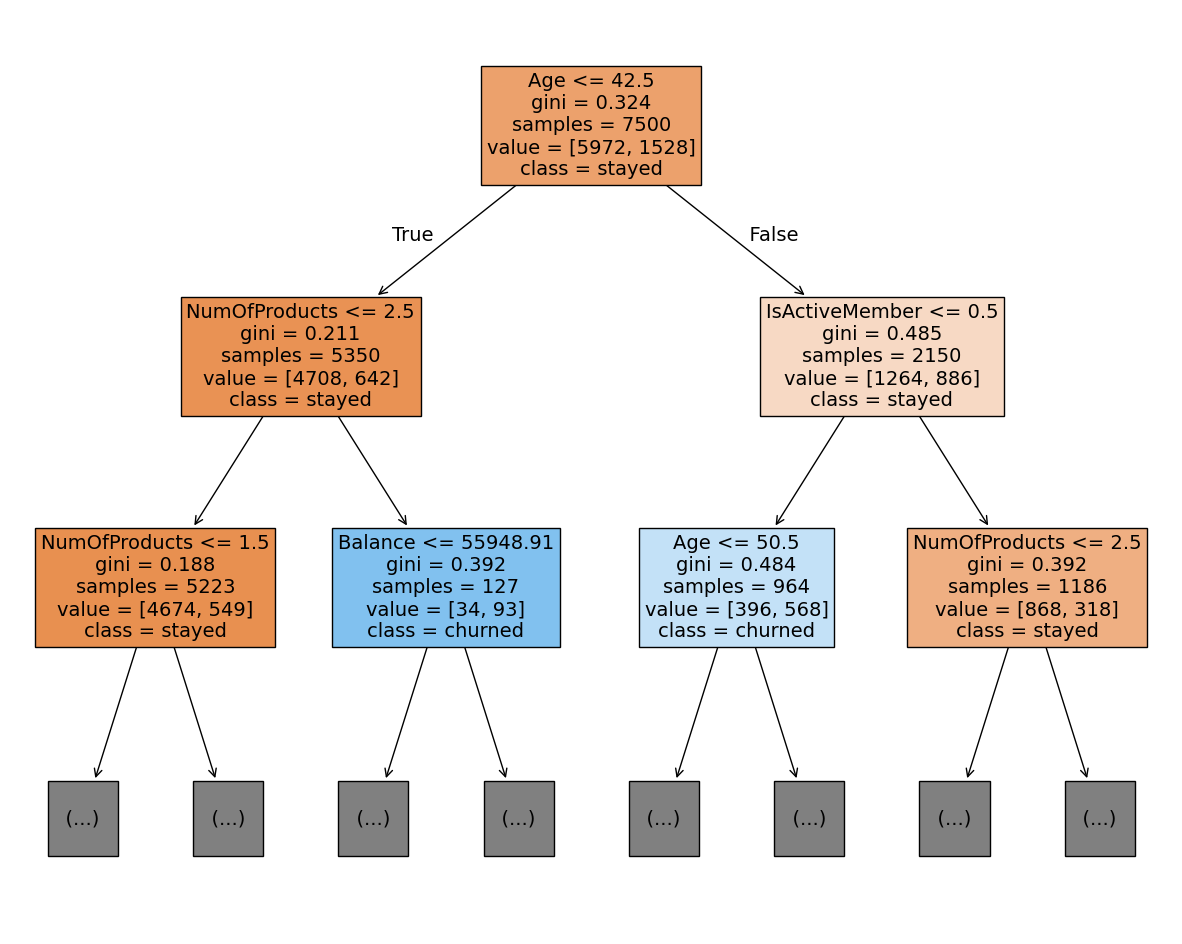

In [14]:
# Plot the tree
# Graficar el árbol
plt.figure(figsize=(15,12))
plot_tree(decision_tree, max_depth=2, fontsize=14, feature_names=X.columns, 
          class_names={0:'stayed', 1:'churned'}, filled=True);
plt.show()

¿Cómo leemos este gráfico? La primera línea de información en cada nodo es la característica y el punto de división que el modelo identificó como más predictivo. En otras palabras, esta es la pregunta que se hace en esa división. Para nuestro nodo raíz, la pregunta fue: _¿El cliente tiene menos de o igual a 42.5 años?_

En cada nodo, si la respuesta a la pregunta que hace es "sí", la muestra se movería al nodo hijo a la izquierda. Si la respuesta es "no", la muestra iría al nodo hijo a la derecha.

`gini` se refiere a la _impureza de Gini_ del nodo. Esta es una forma de medir qué tan "puro" es un nodo. El valor puede variar de 0 a 0.5. Una puntuación de Gini de 0 significa que no hay impureza&mdash;el nodo es una hoja, y todas sus muestras son de una sola clase. Una puntuación de 0.5 significa que las clases están igualmente representadas en ese nodo.

`samples` es simplemente cuántas muestras hay en ese nodo, y `value` indica cuántas de cada clase hay en el nodo. Volviendo al nodo raíz, tenemos `value = [5972, 1528]`. Nótese que estos números suman 7,500, que es el número de muestras en el nodo. Esto nos dice que 5,972 clientes en este nodo permanecieron (y=0) y 1,528 clientes abandonaron (y=1).

Por último, tenemos `class`. Esto nos indica la clase mayoritaria de las muestras en cada nodo.


Este gráfico nos dice que, si solo pudiéramos hacer una única división en una sola variable, la que más nos ayudaría a predecir si un cliente cancelará es su edad.

Si miramos los nodos en la profundidad uno, notamos que el número de productos y si el cliente es o no un miembro activo también son predictores fuertes (en relación con las características que tenemos) de si cancelarán o no.

Esto es una buena indicación de que podría valer la pena volver a tu Análisis Exploratorio de Datos y examinar estas características más de cerca.

Finalmente, vale la pena señalar que no hay una sola pregunta que se pueda hacer&mdash;para cualquier característica&mdash;que cause que la mayoría de las muestras en uno de los nodos hijos sean de la clase "cancelado". El árbol debe llegar a una profundidad dos (es decir, se deben hacer dos preguntas) antes de que esto suceda.


Si has completado con éxito el material anterior, ¡felicidades! Ahora entiendes cómo usar Python para construir e interpretar un modelo de árbol de decisión. En adelante, puedes comenzar a usar Python para construir árboles de decisión con tus propios datos.


<a id='2'></a>
# Ajustar y validar árboles de decisión con Python

**Importante:** Esta parte del cuaderno corresponde con el video "Ajustar y validar árboles de decisión con Python", pero se basa en el código de un video anterior. Si aún no lo has hecho, ejecuta todas las celdas anteriores. Puedes hacer esto fácilmente yendo a "Celda" en el menú en la parte superior del cuaderno y haciendo clic en "Ejecutar todo lo anterior" en el menú desplegable.

A lo largo de los siguientes ejercicios, aprenderás a usar Python para ajustar y validar mediante validación cruzada un modelo de árbol de decisión con scikit-learn. Antes de comenzar con este ejercicio de programación, recomendamos encarecidamente ver la conferencia en video sobre los temas asociados.


Todo la información que necesitas para resolver esta tarea está en este cuaderno, y todo el código que implementarás tendrá lugar dentro de este cuaderno.


Temas de enfoque incluyen:

* Usar `GridSearchCV` para ajustar los siguientes hiperparámetros con validación cruzada:
  - `max_depth`
  - `min_samples_leaf`


A medida que avanzamos, puedes encontrar instrucciones sobre cómo instalar las bibliotecas requeridas a medida que surjan en este cuaderno.


## Una nota sobre el flujo de trabajo de modelado y la selección de modelos

El modelo de árbol de decisión ajustado en este cuaderno será referenciado en los cuadernos siguientes para bosque aleatorio y XGBoost, que modelan los mismos datos. Debido a esto, construiremos todos nuestros modelos en todos estos cuadernos, y la selección de modelos tendrá lugar en el cuaderno final. El modelo campeón será aquel que tenga el mejor rendimiento en los datos de validación. Solo este modelo final será evaluado usando los datos de prueba.

Este enfoque tiene una limitación. Estamos usando los mismos datos para ajustar los hiperparámetros que los que usamos para realizar la selección de modelos. Esto corre el riesgo de sobreajustar potencialmente el modelo a los datos de validación.

Idealmente, con suficiente tiempo y datos, ajustaríamos los hiperparámetros de los modelos, luego calificaríamos todos los modelos en datos de validación _separados_ y realizaríamos la selección de modelos basada en estas puntuaciones. Finalmente, el modelo campeón sería calificado en los datos de reserva de prueba para obtener una estimación de cómo se puede esperar que el modelo rinda en datos nuevos y no vistos.


## Declaraciones de importación

Esta es una continuación del cuaderno para el modelo de árbol de decisión base. Consulte (y ejecute) las declaraciones de importación anteriores.

La única importación adicional es `GridSearchCV` del módulo `model_selection` de scikit-learn. Esto es lo que usaremos para realizar la búsqueda en cuadrícula para ajustar los hiperparámetros del modelo.


In [15]:
# Import GridSearchCV
from sklearn.model_selection import GridSearchCV

<a id="tuning"></a>
## Ajuste de hiperparámetros con validación cruzada

Validar un modelo usando GridSearchCV se puede hacer de varias maneras diferentes. Si encuentras cuadernos en línea que otras personas han escrito, probablemente pronto lo descubrirás por ti mismo. Pero todas las variaciones deben cumplir con los mismos requisitos generales. (Consulta la [documentación de GridSearchCV](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html#sklearn.model_selection.GridSearchCV) para más información.)

El formato presentado a continuación es paso a paso, lo que facilita su seguimiento.

* Crear un diccionario de hiperparámetros para buscar:

  - clave = nombre del hiperparámetro (cadena)
  - valor = valores a buscar (lista)


In [16]:
# Assign a dictionary of hyperparameters to search over
# Asignar un diccionario de hiperparámetros para buscar
tree_para = {'max_depth':[4,5,6,7,8,9,10,11,12,15,20,30,40,50],
             'min_samples_leaf': [2, 5, 10, 20, 50]}

Crear un diccionario de métricas de puntuación para capturar. Estas métricas pueden ser seleccionadas de las [opciones integradas](https://scikit-learn.org/stable/modules/model_evaluation.html#scoring-parameter) de scikit-learn o definidas por el usuario. Para este ejercicio, capturaremos precisión, exactitud, recuperación y puntuación F1 para poder examinar todas ellas. Las métricas se ingresan como cadenas.


In [17]:
# Assign a dictionary of scoring metrics to capture
# Asignar un diccionario de métricas de evaluación para capturar
scoring = {'accuracy', 'precision', 'recall', 'f1'}

* Instanciar el clasificador (y establecer el `random_state`)


In [18]:
# Instantiate the classifier
tuned_decision_tree = DecisionTreeClassifier(random_state = 42)

Instanciar el objeto `GridSearchCV`. Pasar como argumentos:
  - El clasificador (`tuned_decision_tree`)
  - El diccionario de hiperparámetros a buscar (`tree_para`)
  - El diccionario de métricas de puntuación (`scoring`)
  - El número de pliegues de validación cruzada que deseas (`cv=5`)
  - La métrica de puntuación que quieres que GridSearch utilice cuando seleccione el modelo "mejor" (es decir, el modelo que funciona mejor en promedio en todos los pliegues de validación) (`refit='f1'`*)

    \* La razón por la que se llama `refit` es porque una vez que el algoritmo encuentra la combinación de hiperparámetros que resulta en la mejor puntuación promedio en todos los pliegues de validación, entonces volverá a ajustar este modelo a _todos_ los datos de entrenamiento. Recuerda, hasta ahora, con una validación cruzada de 5 pliegues, el modelo solo ha sido ajustado en el 80% (4/5) de los datos de entrenamiento, porque el 20% restante se reservó como un pliegue de validación.

* Ajustar los datos (`X_train`, `y_train`) al objeto `GridSearchCV` (`clf`)

Dependiendo del número de diferentes hiperparámetros que elijas, del número de combinaciones que busques, del tamaño de tus datos y de tus recursos computacionales disponibles, esto podría tomar mucho tiempo.


In [19]:
# Instantiate the GridSearch
# Instanciar el GridSearch
clf = GridSearchCV(tuned_decision_tree, 
                   tree_para,          # parametros a buscar
                   scoring = list(scoring),  # métricas de evaluación a capturar ojo debe ser una lista
                   cv=5,               # número de folds para cross-validation
                   refit="f1")         # reajustar el modelo con los mejores hiperparámetros

# Fit the model
clf.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [4, 5, ...], 'min_samples_leaf': [2, 5, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","['precision', 'f1', ...]"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'f1'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score

Ahora que el modelo está ajustado y validado cruzadamente, podemos usar el atributo `best_estimator_` para inspeccionar los valores de los hiperparámetros que produjeron la puntuación F1 más alta durante la validación cruzada.


In [20]:
# Examine the best model from GridSearch
clf.best_estimator_

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",8
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",20
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current n

In [21]:
print(f"Mejor estimador: {clf.best_estimator_.__dict__}")

Mejor estimador: {'criterion': 'gini', 'splitter': 'best', 'max_depth': 8, 'min_samples_split': 2, 'min_samples_leaf': 20, 'min_weight_fraction_leaf': 0.0, 'max_features': None, 'max_leaf_nodes': None, 'random_state': 42, 'min_impurity_decrease': 0.0, 'class_weight': None, 'ccp_alpha': 0.0, 'monotonic_cst': None, 'feature_names_in_': array(['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts',
       'HasCrCard', 'IsActiveMember', 'EstimatedSalary',
       'Geography_Germany', 'Geography_Spain'], dtype=object), 'n_features_in_': 10, 'n_outputs_': 1, 'classes_': array([0, 1]), 'n_classes_': np.int64(2), 'max_features_': 10, 'tree_': <sklearn.tree._tree.Tree object at 0x000001817122A1E0>}


El atributo `best_score_` devuelve la mejor puntuación media de F1 entre los diferentes pliegues en todas las combinaciones de hiperparámetros. Tenga en cuenta que si hubiéramos establecido `refit='recall'` cuando instanciamos nuestro objeto `GridSearchCV` anteriormente, entonces llamar a `best_score_` devolvería la mejor puntuación de recall, y los mejores parámetros podrían no ser los mismos que los que aparecen en la celda anterior, porque el modelo sería seleccionado en función de una métrica diferente.


In [22]:
print(f"Best Avg. Validation Score: {clf.best_score_:.4f}")

Best Avg. Validation Score: 0.5607


Aunque la puntuación F1 de 0.561 es significativamente mejor que la puntuación F1 del modelo base de 0.494, no es una comparación justa, porque el modelo base fue evaluado en los datos de prueba y el modelo ajustado fue evaluado contra pliegues de validación que provienen de los datos de entrenamiento.

Recuerda que cuando realizamos nuestra búsqueda en cuadrícula, especificamos que también queríamos capturar precisión, recall y exactitud. La razón de hacer esto es que es difícil interpretar una puntuación F1. Estas otras métricas son mucho más directamente interpretables, por lo que vale la pena conocerlas.

La siguiente celda define una función auxiliar que extrae estas puntuaciones del objeto `GridSearchCV` ajustado y devuelve un dataframe de pandas con las cuatro puntuaciones del modelo con la mejor puntuación F1 promedio durante la validación. Esta función nos ayudará más adelante cuando queramos agregar los resultados de otros modelos a la tabla.


In [24]:
def make_results(model_name, model_object):
    '''
    Accepts as arguments a model name (your choice - string) and
    a fit GridSearchCV model object.
  
    Returns a pandas df with the F1, recall, precision, and accuracy scores
    for the model with the best mean F1 score across all validation folds.  

    Acepta como argumentos un nombre de modelo (a su elección - cadena) y
    un objeto de modelo GridSearchCV ajustado.

    Retorna un df de pandas con las puntuaciones F1, recall, precision y accuracy
    para el modelo con la mejor puntuación media F1 en todos los pliegues de

    '''

    # Get all the results from the CV and put them in a df
    cv_results = pd.DataFrame(model_object.cv_results_)

    # Isolate the row of the df with the max(mean f1 score)
    best_estimator_results = cv_results.iloc[cv_results['mean_test_f1'].idxmax(), :]

    # Extract accuracy, precision, recall, and f1 score from that row
    f1 = best_estimator_results.mean_test_f1
    recall = best_estimator_results.mean_test_recall
    precision = best_estimator_results.mean_test_precision
    accuracy = best_estimator_results.mean_test_accuracy
  
    # Create table of results
    table = pd.DataFrame({'Model': [model_name],
                        'F1': [f1],
                        'Recall': [recall],
                        'Precision': [precision],
                        'Accuracy': [accuracy]
                         }
                        )
  
    return table

In [25]:
# Call the function on our model
result_table = make_results("Tuned Decision Tree", clf)

Podemos guardar estos resultados y abrirlos en otro cuaderno si queremos agregarles. Guardaremos como un archivo .csv usando `to_csv()`.


In [26]:
# Save results table as csv
result_table.to_csv("Results.csv")

In [27]:
# View the results
result_table

,Model,F1,Recall,Precision,Accuracy
0,Tuned Decision Tree,0.560655,0.469255,0.701608,0.8504


Estos resultados muestran que el rendimiento de nuestro modelo no es genial, pero tampoco es terrible. Quizá otro tipo de modelo funcione mejor...


¡Felicidades! Has completado este laboratorio. Sin embargo, es posible que no notes una marca de verificación verde junto a este elemento en la plataforma de Coursera. Por favor, continúa con tu progreso independientemente de la marca de verificación. Solo haz clic en el icono de "guardar" en la parte superior de este cuaderno para asegurarte de que tu trabajo ha sido registrado.

Ahora entiendes cómo usar Python para ajustar y validar cruzadamente un modelo de árbol de decisión. En adelante, puedes comenzar a usar Python para ajustar y validar cruzadamente modelos de árbol de decisión con tus propios datos.
